<a href="https://colab.research.google.com/github/DuncDennis/MARBLE/blob/Colab-examples/colab-examples/colab_examples_install_and_load.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MARBLE in Google Colab

Use this colab notebook to install and load the MARBLE package.

## Installation and imports

In [2]:
# Clone the MARBLE repository (change URL if needed). Move to the marble directory.
!git clone https://github.com/agosztolai/MARBLE.git

%cd MARBLE

Cloning into 'MARBLE'...
remote: Enumerating objects: 7527, done.
remote: Counting objects: 100% (535/535), done.
remote: Compressing objects: 100% (153/153), done.
remote: Total 7527 (delta 435), reused 386 (delta 381), pack-reused 6992 (from 1)
Receiving objects: 100% (7527/7527), 230.94 MiB | 20.09 MiB/s, done.
Resolving deltas: 100% (5300/5300), done.
/content/MARBLE


In [3]:
# Install requirements (see here https://gist.github.com/ameya98/b193856171d11d37ada46458f60e73e7)
import torch

def format_pytorch_version(version):
  return version.split('+')[0]

TORCH_version = torch.__version__
TORCH = format_pytorch_version(TORCH_version)

def format_cuda_version(version):
  return 'cu' + version.replace('.', '')

CUDA_version = torch.version.cuda
CUDA = format_cuda_version(CUDA_version)

!pip install torch-scatter -f https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html
!pip install torch-cluster -f https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html
!pip install torch-spline-conv -f https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html
!pip install torch-geometric==2.1.0

Looking in links: https://data.pyg.org/whl/torch-2.5.1+cu121.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 43.9 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.5.1+cu121.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 51.1 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.5.1+cu121.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 39.9 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.5.1+cu121.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 994.8/994.8 kB 7.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 467.5/467.5 kB 10.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Reason for being yanked: Missing ninja templates
  Created wheel for torch-geometric: filename=torch_geometric-2.1.0-py3-none-any.whl size=687143 sha256=1e3c5e19b7fc0116401eb676834bcb97fc86fe6163d97543dfa2ab366e771438
  Stored in directory: /root/.cache/pip/wheels/9b/68/8e/fc6b4a08d5aef2f8c

In [4]:
# locally install the MARBLE package.
!pip install -e .

Obtaining file:///content/MARBLE
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.2/510.2 kB 12.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 239.8/239.8 kB 17.3 MB/s eta 0:00:00
  Building editable for MARBLE (pypr

## Example: Vector field over flat surface

Taken from https://github.com/agosztolai/MARBLE/blob/main/examples/toy_examples/ex_vector_field_flat_surface.py

In [5]:
# import required packages
"""This example illustrates MARBLE for a vector field on a flat surface."""
import numpy as np
import sys
from MARBLE import plotting, preprocessing, dynamics, net, postprocessing
import matplotlib.pyplot as plt

In [7]:
# Define four different vector signals

def f0(x): # constant
    return x * 0 + np.array([-1, -1])

def f1(x): # constant
    return x * 0 + np.array([1, 1])

def f2(x): # rotating
    eps = 1e-1
    norm = np.sqrt((x[:, [0]] + 1) ** 2 + x[:, [1]] ** 2 + eps)
    u = x[:, [1]] / norm
    v = -(x[:, [0]] + 1) / norm
    return np.hstack([u, v])

def f3(x): # rotating
    eps = 1e-1
    norm = np.sqrt((x[:, [0]] - 1) ** 2 + x[:, [1]] ** 2 + eps)
    u = x[:, [1]] / norm
    v = -(x[:, [0]] - 1) / norm
    return np.hstack([u, v])

In [8]:
# generate simple vector fields
# f0: linear, f1: point source, f2: point vortex, f3: saddle
n = 512
x = [dynamics.sample_2d(n, [[-1, -1], [1, 1]], "random", seed=i) for i in range(4)]
y = [f0(x[0]), f1(x[1]), f2(x[2]), f3(x[3])]  # evaluated functions

In [9]:
# construct data object
data = preprocessing.construct_dataset(x, y)

# train model
model = net(data, params={'inner_product_features': False,
                          'diffusion': False})
model.fit(data)

# evaluate model on data
data = model.transform(data)
data = postprocessing.cluster(data)
data = postprocessing.embed_in_2D(data)


---- Embedding dimension: 2
---- Signal dimension: 2
Embedding dimension <= 2, so manifold computations are disabled!

---- Computing kernels ... 
---- Computing full spectrum ... (if this takes too long, then run construct_dataset() with number_of_eigenvectors specified) 
---- Settings: 

inner_product_features : False
diffusion : False
epochs : 100
batch_size : 64
lr : 0.01
momentum : 0.9
dropout : 0.0
batch_norm : batch_norm
hidden_channels : [32]
bias : True
order : 2
frac_sampled_nb : -1
include_positions : False
include_self : True
out_channels : 3
vec_norm : False
emb_norm : False
seed : 0
dim_signal : 2
dim_emb : 2
n_sampled_nb : -1

---- Number of features to pass to the MLP:  14
---- Total number of parameters:  644

Using device cpu

---- Training network ...

---- Timestamp: 20250116-105924

Epoch: 0, Training loss: 1.175637, Validation loss: 1.2100, lr: 0.0100 *
Epoch: 1, Training loss: 1.043240, Validation loss: 1.0525, lr: 0.0100 *
Epoch: 2, Training loss: 1.049259, Val

/content/MARBLE/MARBLE/main.py:413: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.

Performed umap embedding on embedded results.


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


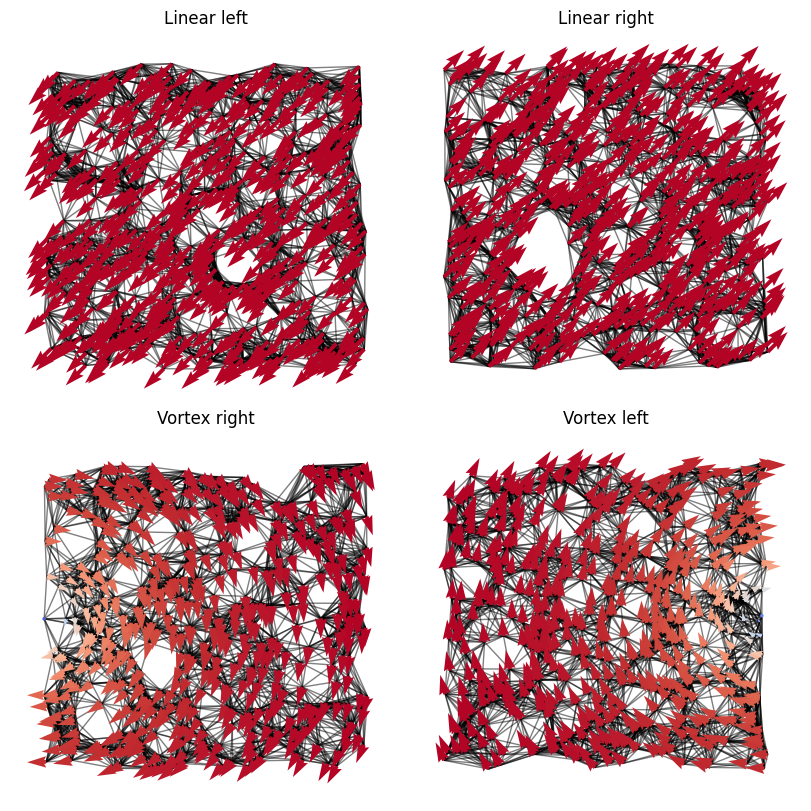

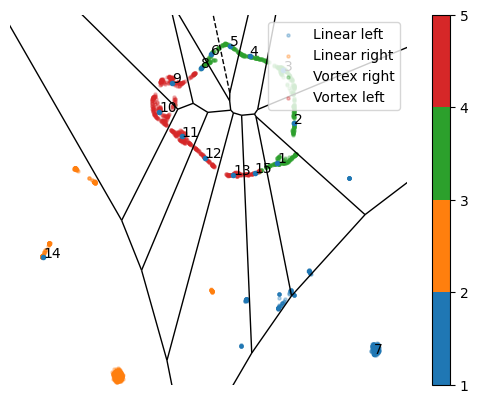

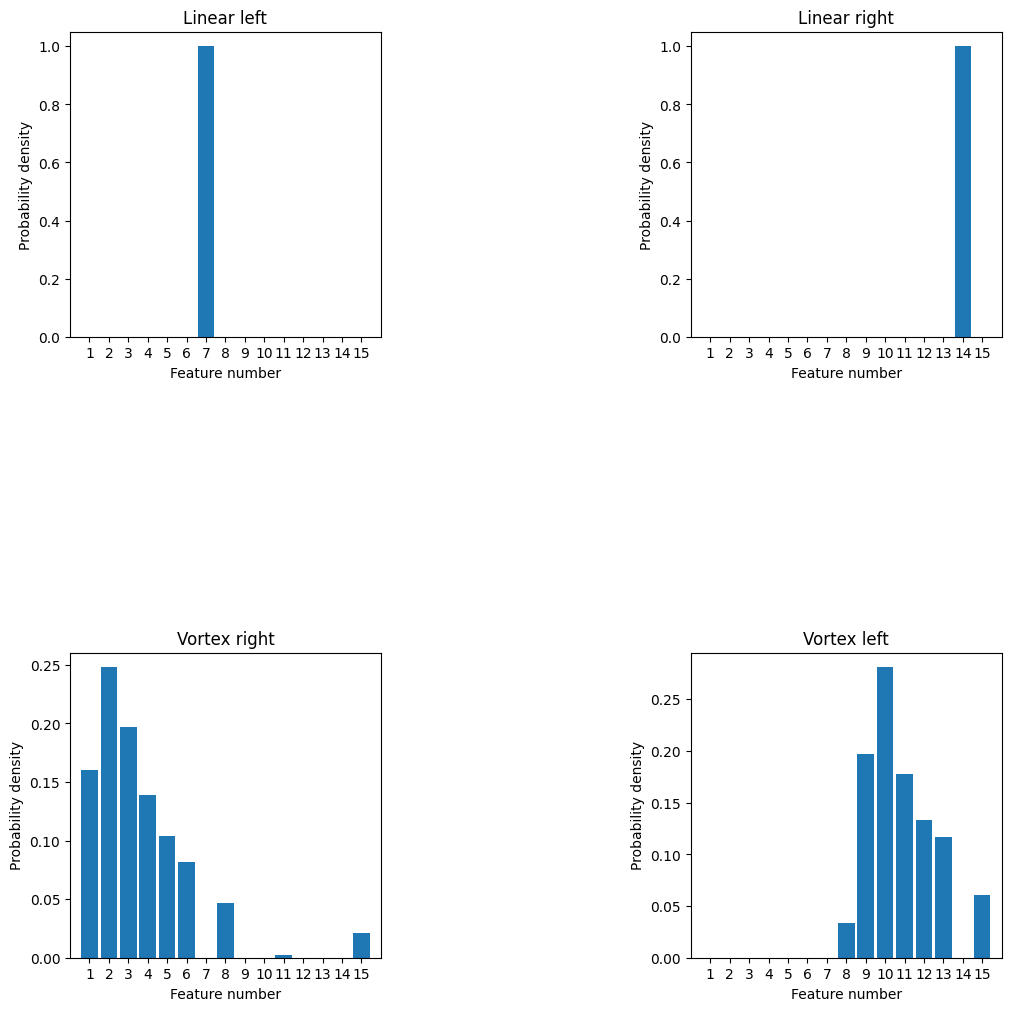

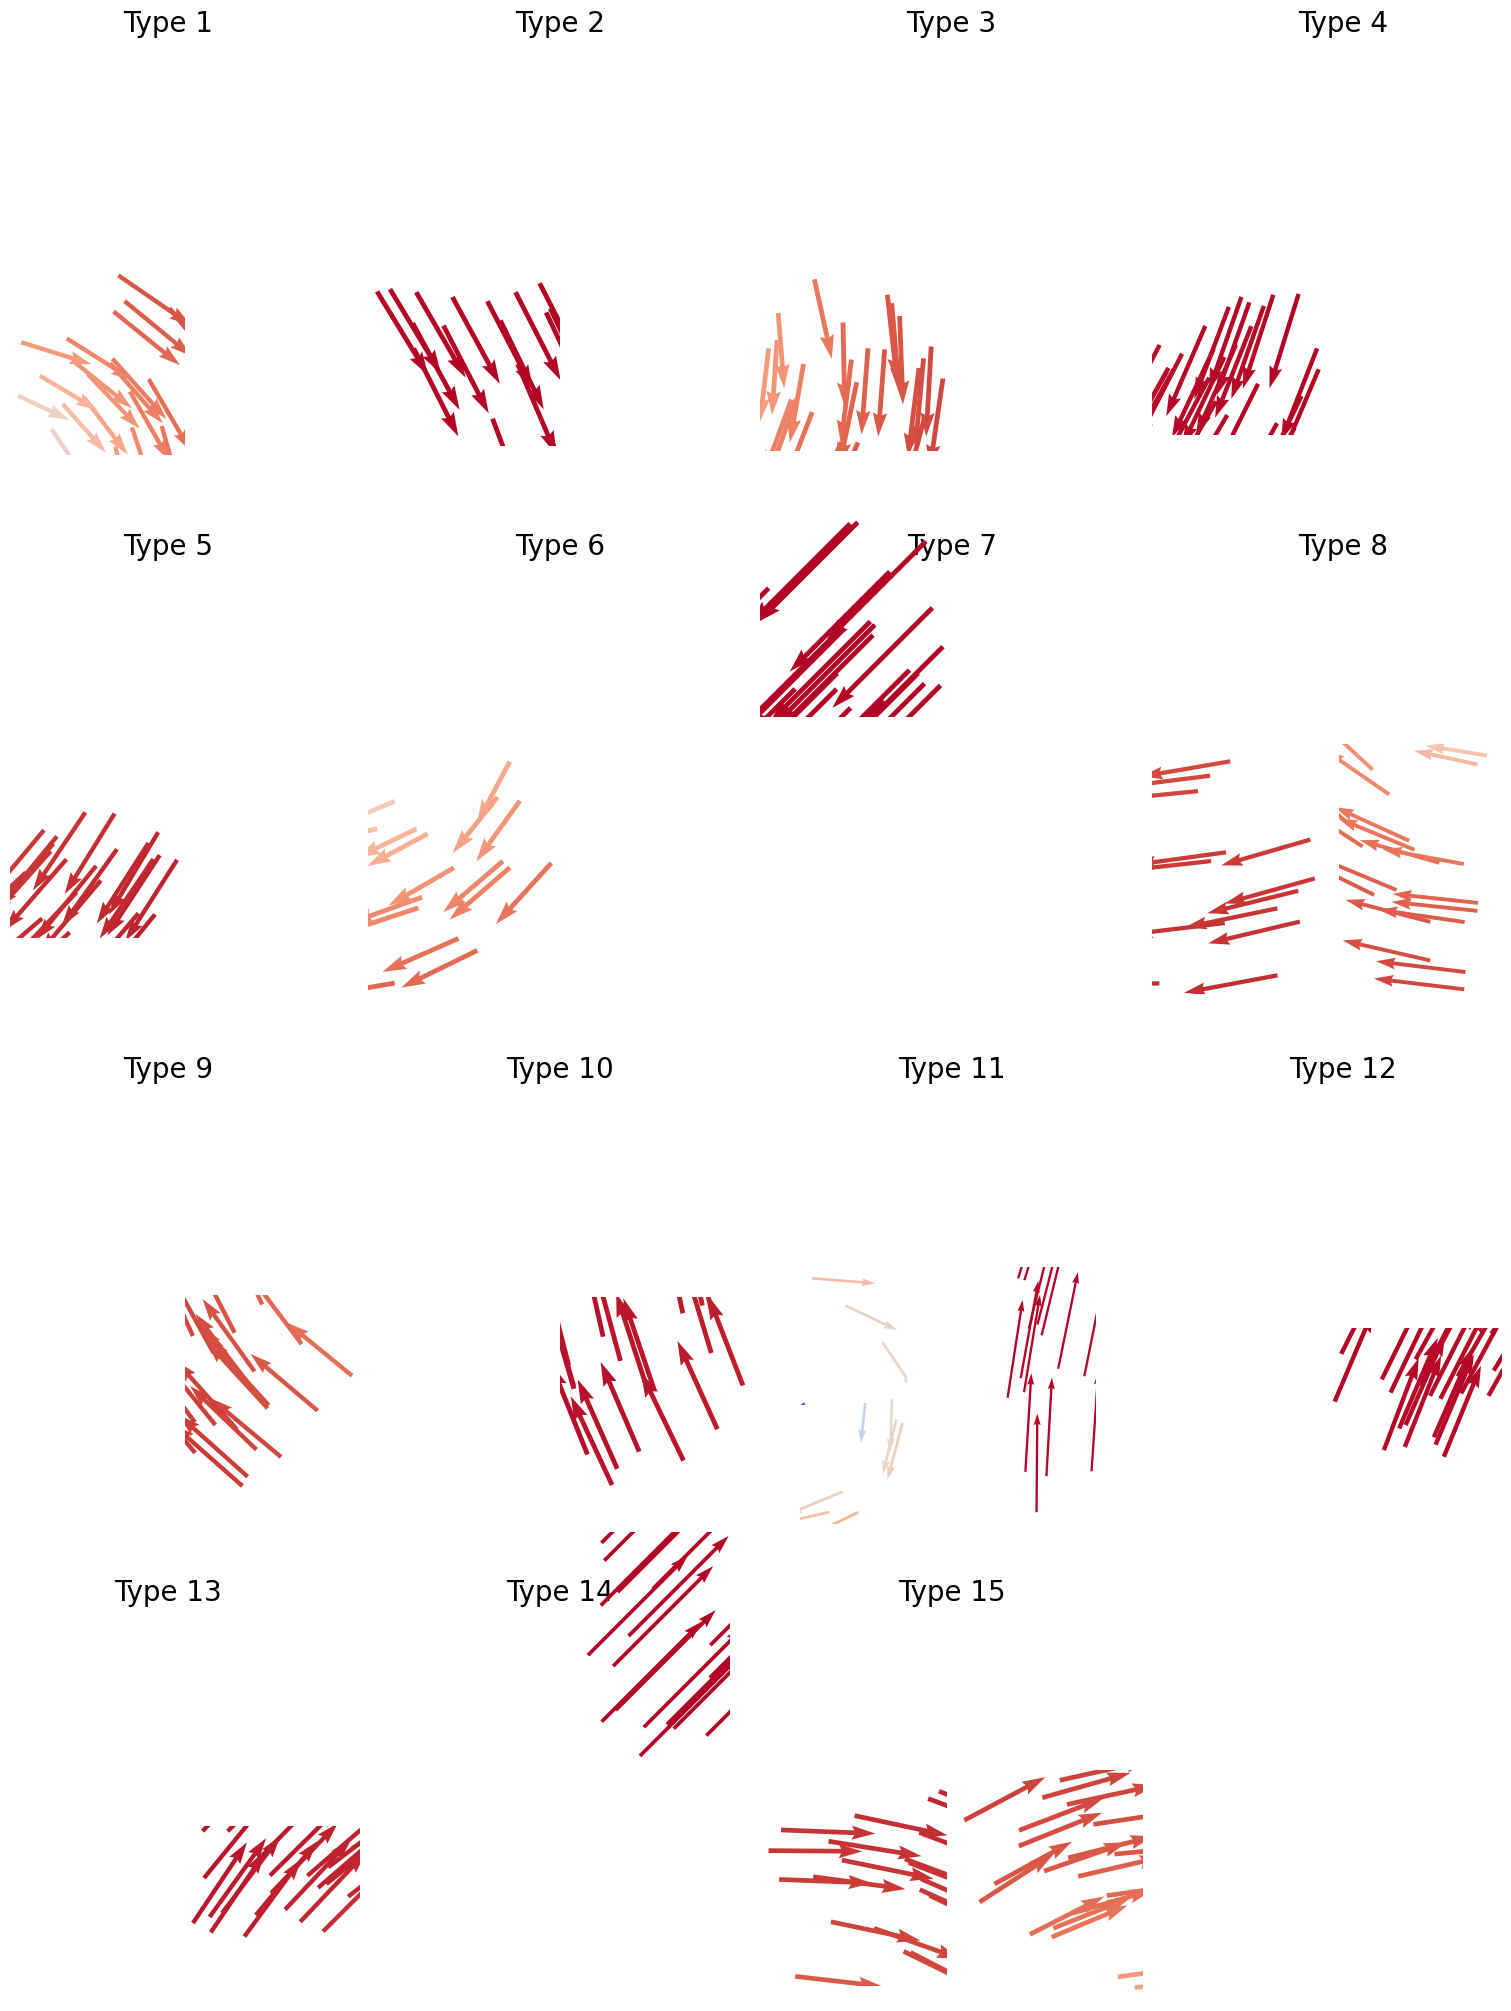

In [10]:
# plot results
titles = ["Linear left", "Linear right", "Vortex right", "Vortex left"]
plotting.fields(data, titles=titles, col=2, width=0.01)
plt.savefig('fields.svg')
plotting.embedding(data, data.y.numpy(), titles=titles, clusters_visible=True)
plt.savefig('embedding.svg')
plotting.histograms(data, titles=titles)
plt.savefig('histogram.svg')
plotting.neighbourhoods(data)
plt.savefig('neighbourhoods.svg')
plt.show()